# Evaluasi Performa Real-Time CASME II
Notebook ini menghitung kecepatan inferensi (latency/real-time performance) untuk dataset CASME II secara *end-to-end* tanpa melihat performa klasifikasi. Pipeline mengikuti arsitektur WebSocket streaming/backend.

In [6]:
import os
os.environ['MODEL_N_TTA'] = '1'
os.environ['MODEL_STRICT_NOTEBOOK_PARITY'] = '0'

import os
import glob
import time
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt

# pulse-live modules
import sys
sys.path.append("..")
from src.face.modules import FaceLandmark, FaceRoiPoints
from src.face.modules.face_aligner import FaceAligner
from src.optical_flow.modules import TVL1
from src.apex.modules import ApexPhaseSpotterROI, ApexSmoother
from src.models.inferencer import load_inferencer_from_env


In [7]:
# Inisialisasi Modul
landmarker = FaceLandmark()
aligner = FaceAligner()
tvl1 = TVL1(fast_mode=True)
phase_spotter = ApexPhaseSpotterROI()

# Inisialisasi Model Inferensi
try:
    inf = load_inferencer_from_env()
    print(f"Model loaded successfully: {type(inf).__name__}")
except Exception as e:
    print(f"Failed to load inferencer: {e}")
    inf = None

# Warm-up GPU untuk menghindari Cold Start (200ms+) di awal
if inf is not None:
    print("Warming up GPU...")
    max_t = getattr(inf, 'max_seq_len', 150)
    dummy_flow = np.zeros((max_t, 5, 2, 32, 32), dtype=np.float32)
    import torch
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False # Matikan autotuner agar tidak mencari algoritma baru tiap frame berubah
        torch.cuda.synchronize()

    _ = inf.predict_flow(dummy_flow)
    print("Warm-up selesai!")


Model loaded successfully: SpatioTemporalInferencer


W0000 00:00:1782636456.045656  105820 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782636456.048634  105820 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782636456.049827  105843 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782636456.051372  105829 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782636456.058899  105840 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782636456.064324  105844 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782636456.068873  105844 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 

In [ ]:
casme2_dir = "/home/inadio/datasets/secondaries/casme-2"
video_files = glob.glob(os.path.join(casme2_dir, "*", "*.avi"))
print(f"Found {len(video_files)} videos in CASME II dataset.")

roi_defs = [
    frozenset(FaceRoiPoints.LEFT_EYE_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYE_POINTS),
    frozenset(FaceRoiPoints.LIPS_POINTS),
    frozenset(FaceRoiPoints.LEFT_EYEBROW_POINTS),
    frozenset(FaceRoiPoints.RIGHT_EYEBROW_POINTS),
]
tile_size = (32, 32)
margin = 0.05
cols = 3
rows = int(np.ceil(len(roi_defs) / cols))

latency_data = []

# Untuk mempercepat, kita ambil subset (misal: 20 video pertama)
for i, video_path in enumerate(video_files[:50]):
    cap = cv2.VideoCapture(video_path)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    
    if len(frames) == 0:
        continue
        
    last_crops = None
    magnitudes = []
    flows = []
    
    video_latencies = {
        "landmark": [],
        "flow": [],
    }
    
    for frame in frames:
        # Landmark & ROI
        start_landmark = time.time()
        landmarks = landmarker.detect(frame)
        try:
            aligned, aligned_landmarks = aligner.align_with_landmarks(image=frame, landmarks=landmarks)
        except Exception:
            aligned = frame
            aligned_landmarks = landmarks
            
        crops = []
        for roi_points in roi_defs:
            try:
                roi, _ = landmarker.crop_roi(
                    image=frame,
                    landmark_result=aligned_landmarks,
                    roi_points=roi_points,
                    margin=margin,
                    target_size=tile_size,
                )
            except Exception:
                roi = np.zeros((tile_size[1], tile_size[0], 3), dtype=np.uint8)
            crops.append(roi)
        video_latencies["landmark"].append((time.time() - start_landmark) * 1000)
        
        # TVL1 Flow
        if last_crops is not None:
            start_flow = time.time()
            pairs = list(zip(last_crops, crops))
            flows_batch = tvl1.compute_batch(pairs, download=True)
            
            flow_canvas = np.zeros(
                (rows * tile_size[1], cols * tile_size[0], 2),
                dtype=np.float32,
            )
            roi_magnitudes = []
            for idx, flow in enumerate(flows_batch):
                r, c = divmod(idx, cols)
                y1, y2 = r * tile_size[1], (r + 1) * tile_size[1]
                x1, x2 = c * tile_size[0], (c + 1) * tile_size[0]
                flow_canvas[y1:y2, x1:x2, :] = flow
                roi_magnitudes.append(float(np.mean(np.hypot(flow[..., 0], flow[..., 1]))))
            
            mag = float(np.mean(roi_magnitudes))
            video_latencies["flow"].append((time.time() - start_flow) * 1000)
            
            magnitudes.append(mag)
            flows.append(flow_canvas)
            
        last_crops = crops
        
    # Spotting & Inference
    if inf is None or len(magnitudes) == 0:
        continue
        
    start_spot = time.time()
    from scipy.signal import savgol_filter
    try:
        window_length = ApexSmoother.calculate_window_length(len(magnitudes))
        polyorder = ApexSmoother.calculate_polyorder(window_length)
        smoothed = [float(x) for x in savgol_filter(magnitudes, window_length, polyorder)]
        windows, meta = phase_spotter.detect_windows_from_signal(magnitudes)
    except Exception:
        pass
    spotting_latency = (time.time() - start_spot) * 1000
    
    n_roi = len(roi_defs)
    frames_for_inf = []
    for canvas in flows:
        canvas = np.asarray(canvas, dtype=np.float32)
        tiles = []
        for idx in range(n_roi):
            r, c = divmod(idx, cols)
            y1, y2 = r * tile_size[1], (r + 1) * tile_size[1]
            x1, x2 = c * tile_size[0], (c + 1) * tile_size[0]
            tiles.append(canvas[y1:y2, x1:x2, :].transpose(2, 0, 1))
        frames_for_inf.append(np.stack(tiles, axis=0))
        
    flow_array = np.stack(frames_for_inf, axis=0) # (T, N_roi, 2, H, W)
    
    start_infer = time.time()
    result = inf.predict_flow(flow_array)
    infer_latency = (time.time() - start_infer) * 1000
    
    latency_data.append({
        "video": os.path.basename(video_path),
        "landmark_avg_ms": np.mean(video_latencies["landmark"]),
        "flow_avg_ms": np.mean(video_latencies["flow"]),
        "spotting_ms": spotting_latency,
        "model_infer_ms": infer_latency,
    })
    
    if i % 5 == 0:
        print(f"Processed {i+1} videos...")
        
df = pd.DataFrame(latency_data)
df.head()


Found 257 videos in CASME II dataset.


W0000 00:00:1782636463.643731  105972 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782636463.647785  105972 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782636463.649114  105995 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782636463.651763  105973 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782636463.662116  105992 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processed 1 videos...


W0000 00:00:1782636469.202056  106058 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782636469.206138  106058 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782636469.207789  106081 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782636469.209616  106060 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782636469.219430  106075 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782636474.808387  106151 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782636474.812526  106151 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 

Processed 6 videos...


...

Processed 11 videos...


W0000 00:00:1782636533.065314  107232 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782636533.067531  107232 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782636533.068888  107255 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782636533.070677  107239 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782636533.078770  107238 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782636537.957630  107285 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782636537.960336  107285 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 

Processed 16 videos...


W0000 00:00:1782636560.966917  107835 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782636560.969771  107835 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1782636560.970919  107858 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.2.8-0ubuntu0.24.04.2), renderer: Mesa Intel(R) Graphics (RPL-S)
W0000 00:00:1782636560.972386  107836 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782636560.982377  107852 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1782636562.829632  107882 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1782636562.833017  107882 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 

,video,landmark_avg_ms,flow_avg_ms,spotting_ms,model_infer_ms
0,EP02_01f.avi,11.641072,12.982605,1.111269,33.148289
1,EP03_02.avi,11.085812,11.369479,1.013041,28.980017
2,EP04_02.avi,11.797772,12.412581,1.018286,31.965017
3,EP04_03.avi,11.842748,12.478634,0.942707,24.981260
4,EP04_04.avi,11.046368,12.021983,0.986576,27.083635


Total end-to-end latency: 53.94 ms
Rata-rata FPS (berdasarkan pipeline penuh, 1 window): 18.54 FPS


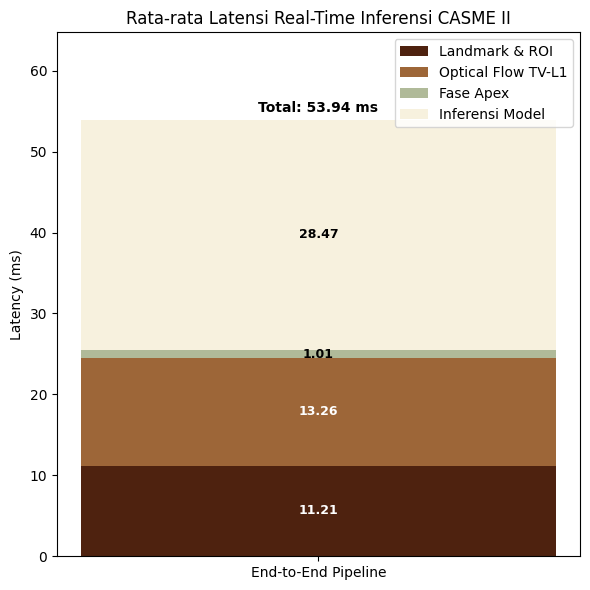

In [9]:
stages = [
    "Landmark & ROI",
    "Optical Flow TV-L1",
    "Fase Apex",
    "Inferensi Model"
]

latency = [
    df["landmark_avg_ms"].mean(),
    df["flow_avg_ms"].mean(),
    df["spotting_ms"].mean(),
    df["model_infer_ms"].mean()
]

total_latency = sum(latency)
print(f"Total end-to-end latency: {total_latency:.2f} ms")
print(f"Rata-rata FPS (berdasarkan pipeline penuh, 1 window): {1000/total_latency:.2f} FPS")

fig, ax = plt.subplots(figsize=(6, 6))
bottom = 0
colors = ["#4E220F", "#9D6638", "#B0BA99", "#F7F1DE"]

for i in range(len(stages)):
    ax.bar(
        "End-to-End Pipeline",
        latency[i],
        bottom=bottom,
        label=stages[i],
        color=colors[i]
    )
    ax.text(
        0,
        bottom + latency[i] / 2,
        f"{latency[i]:.2f}",
        ha="center", va="center", fontsize=9,
        color="white" if i < 2 else "black", fontweight="bold"
    )
    bottom += latency[i]

ax.text(
    0, total_latency + 1,
    f"Total: {total_latency:.2f} ms",
    ha="center", fontsize=10, fontweight="bold"
)
ax.set_ylabel("Latency (ms)")
ax.legend(loc="upper right")
ax.set_ylim(0, total_latency + max(10, total_latency*0.2))
plt.title("Rata-rata Latensi Real-Time Inferensi CASME II")
plt.tight_layout()
plt.show()


In [10]:
print(df)

           video  landmark_avg_ms  flow_avg_ms  spotting_ms  model_infer_ms
0   EP02_01f.avi        11.641072    12.982605     1.111269       33.148289
1    EP03_02.avi        11.085812    11.369479     1.013041       28.980017
2    EP04_02.avi        11.797772    12.412581     1.018286       31.965017
3    EP04_03.avi        11.842748    12.478634     0.942707       24.981260
4    EP04_04.avi        11.046368    12.021983     0.986576       27.083635
5    EP19_01.avi        10.903201    15.151401     1.017809       24.335384
6   EP19_03f.avi        11.121840    14.384912     1.021624       29.159307
7   EP19_05f.avi        11.216943    12.184985     1.160860       28.473616
8   EP19_06f.avi        11.187173    13.890069     1.019001       31.033039
9   EP01_11f.avi        10.689331    14.070984     0.931263       26.183367
10  EP02_04f.avi        10.644664    12.338805     0.998974       29.574156
11  EP03_02f.avi        10.854087    11.706357     0.968933       24.168253
12  EP06_01f

In [ ]:
import matplotlib.pyplot as plt

studies = [
    # "Liong et al. (2021)",
    "Y. Liu et al. (2022)",
    "Fang et al. (2023)",
    "Proposed"
]

processing_time = [122, 31, 28.5, 50.8]   # ms
f1_score = [0.1173, 0.7008, 0.1489, 0.7980]

# Warna dan marker
colors = ["tab:blue", "tab:blue", "tab:blue", "red"]
markers = ["o", "o", "o", "*"]
sizes = [100, 100, 100, 250]

plt.figure(figsize=(8,6))

# Plot setiap titik
for x, y, c, m, s, label in zip(processing_time, f1_score,
                                colors, markers, sizes, studies):
    plt.scatter(x, y, color=c, marker=m, s=s)
    plt.annotate(label,
                 (x, y),
                 xytext=(6,6),
                 textcoords="offset points",
                 fontsize=10)

# Pengaturan grafik
plt.title("Processing Time vs F1-score Comparison", fontsize=14)
plt.xlabel("Processing Time (ms)", fontsize=12)
plt.ylabel("F1-score", fontsize=12)

plt.xlim(20,130)
plt.ylim(0,0.85)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()